# Introducción a LLMs, AI Engineering y Modelos Fundacionales

_GenAI, modelos fundacionales, la arquitectura Transformer y por qué cambió todo_

**Módulo 3 — Introducción a AI Engineering** | DSRP Machine Learning Engineering
**Profesor:** Miguel Arquez

![AI Engineering](assets/header.png)

## 1. ¿Qué es AI Engineering?

**AI Engineering** es la disciplina de **construir aplicaciones encima de modelos pre-entrenados** (típicamente LLMs y modelos fundacionales), en contraste con el **ML Engineering** clásico, donde el foco está en entrenar modelos desde cero sobre datos propios.

| | ML Engineering clásico | AI Engineering |
|---|---|---|
| Punto de partida | datos etiquetados propios | modelo pre-entrenado de tercero |
| Ciclo principal | feature engineering + entrenar | prompts + RAG + evals |
| Costo dominante | cómputo de entrenamiento | inferencia (API calls) |
| Skills | estadística, optimización | diseño de prompts, sistemas, UX |
| Ejemplo | clasificador de churn | asistente de soporte con RAG |

En este módulo construimos las bases: qué son los LLMs, cómo se consumen, cómo se les habla y qué alternativas existen al ecosistema de OpenAI.

## 2. Generative AI vs IA discriminativa

La IA tradicional que vimos en módulos 1 y 2 es **discriminativa**: aprende a discriminar entre clases o a predecir un valor. La IA generativa **modela la distribución de los datos** y puede **generar nuevas muestras**.

| | Discriminativa | Generativa |
|---|---|---|
| Aprende | $P(y \mid x)$ | $P(x)$ o $P(x \mid \text{prompt})$ |
| Devuelve | una etiqueta o un número | nuevo contenido (texto, imagen, audio) |
| Ejemplo | "¿es spam?" | "escribe un email como respuesta" |
| Modelos | regresión logística, RF, XGBoost | GPT, Claude, Gemini, Stable Diffusion, Whisper |

La IA generativa no es nueva (GANs son de 2014, VAEs de 2013), pero los **LLMs basados en Transformers** son los que pusieron la GenAI en el mainstream a partir de 2022.

## 3. Modelos fundacionales (Foundation Models)

Término acuñado por Bommasani et al. (Stanford, 2021):

> _Modelos entrenados a gran escala sobre datos masivos y diversos, con la capacidad de **adaptarse (vía fine-tuning o prompting) a una amplia variedad de tareas downstream**._

Tres propiedades que los caracterizan:

1. **Escala**: cientos de millones a billones de parámetros, terabytes de datos.
2. **Generalidad**: un mismo modelo sirve para resumir, traducir, programar, conversar, clasificar…
3. **Habilidades emergentes**: capacidades que **aparecen al cruzar cierta escala** (razonamiento aritmético, in-context learning, chain-of-thought) y no estaban presentes en modelos más pequeños.

Foundation models incluye LLMs (GPT, Claude, Llama), modelos de visión (CLIP, ViT), modelos multimodales (GPT-4o, Gemini, Claude Opus 4) y de audio (Whisper).

## 4. ¿Qué es un Large Language Model (LLM)?

Un LLM es una red neuronal entrenada para una tarea aparentemente trivial:

> **Predecir el siguiente token** de una secuencia.

Dado un texto $t_1, t_2, \dots, t_{n-1}$, modela:

$$
P(t_n \mid t_1, t_2, \dots, t_{n-1})
$$

A escala, esa simple tarea fuerza al modelo a aprender gramática, hechos del mundo, razonamiento básico, estilos de escritura, código y mucho más. Para generar texto largo, se aplica **autoregresivamente**: predecimos el siguiente token, lo agregamos al contexto y repetimos.

**Cifras de referencia (orden de magnitud):**
- GPT-3 (2020): 175 B parámetros, 300 B tokens de entrenamiento.
- LLaMA 3 (2024): 70 B y 405 B parámetros, 15 T tokens.
- Modelos frontera (2025-2026): trillones de parámetros con MoE (Mixture of Experts).

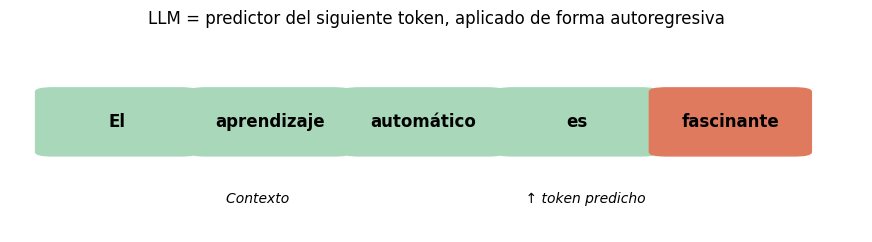

In [1]:
# Visualización: predicción autoregresiva de tokens
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(11, 2.6))
contexto = ['El', 'aprendizaje', 'automático', 'es']
predicho = 'fascinante'
todos = contexto + [predicho]
colors = ['#A8D8B9'] * len(contexto) + ['#E07A5F']

for i, (tok, c) in enumerate(zip(todos, colors)):
    ax.add_patch(patches.FancyBboxPatch(
        (0.05 + i * 0.18, 0.4), 0.15, 0.3,
        boxstyle='round,pad=0.02', color=c,
    ))
    ax.text(0.125 + i * 0.18, 0.55, tok, ha='center', va='center',
            fontsize=12, fontweight='bold')

ax.text(0.5, 0.15, 'Contexto                                                      ↑ token predicho',
        ha='center', fontsize=10, style='italic')
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')
ax.set_title('LLM = predictor del siguiente token, aplicado de forma autoregresiva')
plt.show()

## 5. La revolución del Transformer

Antes de 2017, las arquitecturas dominantes para secuencias eran las **RNN/LSTM**:

- Procesaban tokens **uno a uno** (secuencial → lento, mal aprovecha GPUs).
- Tenían problemas con **dependencias de larga distancia** (gradientes desvanecidos).

En 2017 el paper **"Attention Is All You Need"** (Vaswani et al., Google) propuso una arquitectura nueva: el **Transformer**, basado enteramente en el mecanismo de **atención**. Sus tres ideas clave:

1. **Procesamiento paralelo** de toda la secuencia (no token a token) — explota GPUs.
2. **Self-attention**: cada token mira a todos los demás tokens y pondera su importancia.
3. **Positional encodings**: como no procesa en orden, añade una señal de posición a cada token.

A partir de 2017, casi todos los avances en NLP (y luego visión, audio, código, biología) usan Transformers.

<p align="center">
  <img src="assets/transformer_architecture.png" alt="Arquitectura del Transformer (Vaswani et al., 2017)" width="420"/>
</p>

<p align="center"><em>Arquitectura original del Transformer: encoder (izquierda) y decoder (derecha). Imagen: <a href="https://en.wikipedia.org/wiki/Transformer_(deep_learning_architecture)">Wikipedia / Wikimedia Commons</a>.</em></p>

## 6. Paso a paso: del texto al siguiente token

Veamos qué pasa **dentro del modelo** cuando llamas a una API y le pides que complete un texto. La salida de una sola pasada es **un solo token**; para generar una respuesta larga, los pasos se repiten en bucle.

### Paso 1 — Tokenización

El texto se rompe en piezas pequeñas llamadas **tokens** (subpalabras, no palabras completas). Cada token tiene un ID entero en el vocabulario del modelo (típicamente entre 30 000 y 200 000 entradas).

```
"Aprendizaje automático"
        ↓ tokenizer
["Aprend", "izaje", " auto", "mático"]
        ↓ vocabulario
[58423, 11209, 4031, 88716]
```

Por ahora es solo texto → enteros. Sin semántica todavía.

### Paso 2 — Embeddings de token

Cada ID se busca en una tabla gigante (la `embedding matrix`) y se reemplaza por un **vector denso** (entre 1 024 y 12 288 dimensiones, según el modelo). Ese vector codifica el "significado" del token.

```
ID 58423  →  [0.13, -0.42, 0.88, ..., 0.07]   ← un vector por token
```

Tokens con significados parecidos quedan cerca en este espacio vectorial.

### Paso 3 — Embeddings posicionales

El Transformer procesa todos los tokens **en paralelo**, así que sin ayuda no sabría en qué orden vienen. Para que distinga "el perro mordió al hombre" de "el hombre mordió al perro", le sumamos a cada vector una **señal de posición**: un patrón distinto para la posición 1, la 2, la 3…

$$
\text{vector\_token} = \text{embedding(token)} + \text{posicional(posición)}
$$

#### 🔢 Ejemplo numérico — la fórmula sinusoidal del paper original

Para mantener los números a la vista, usamos $d_{\text{model}} = 4$ (modelos reales usan 768, 4 096, hasta 12 288). La fórmula de Vaswani et al. (2017) es:

$$
\text{PE}(\text{pos},\ 2i) = \sin\!\left(\frac{\text{pos}}{10000^{2i/d}}\right) \qquad
\text{PE}(\text{pos},\ 2i+1) = \cos\!\left(\frac{\text{pos}}{10000^{2i/d}}\right)
$$

Es decir: las **dimensiones pares** usan **seno**, las **impares** usan **coseno**, y el divisor crece con $i$ (las primeras dimensiones oscilan rápido, las últimas oscilan despacio).

Calculemos los vectores para las tres primeras posiciones con $d = 4$:

| pos | dim 0 = sin(pos / 10000⁰) | dim 1 = cos(pos / 10000⁰) | dim 2 = sin(pos / 100) | dim 3 = cos(pos / 100) |
|---|---|---|---|---|
| 0 | sin(0) = **0.000** | cos(0) = **1.000** | sin(0) = **0.000** | cos(0) = **1.000** |
| 1 | sin(1) = **0.841** | cos(1) = **0.540** | sin(0.01) = **0.010** | cos(0.01) = **1.000** |
| 2 | sin(2) = **0.909** | cos(2) = **−0.416** | sin(0.02) = **0.020** | cos(0.02) = **1.000** |

Así, los tres vectores posicionales son:

$$
\text{PE}_0 = [0.000,\ 1.000,\ 0.000,\ 1.000] \quad
\text{PE}_1 = [0.841,\ 0.540,\ 0.010,\ 1.000] \quad
\text{PE}_2 = [0.909,\ -0.416,\ 0.020,\ 1.000]
$$

Cada posición tiene su **huella única**.

#### Cómo se combina con el embedding del token

Supongamos que el embedding aprendido del token `"El"` es:

$$
\text{emb}(\texttt{"El"}) = [0.10,\ -0.20,\ 0.50,\ 0.30]
$$

Si `"El"` está en la **posición 0**, lo que entra al modelo es la suma:

$$
\begin{aligned}
\text{entrada}_0 &= \text{emb}(\texttt{"El"}) + \text{PE}_0 \\
&= [0.10,\ -0.20,\ 0.50,\ 0.30] + [0.000,\ 1.000,\ 0.000,\ 1.000] \\
&= [0.100,\ 0.800,\ 0.500,\ 1.300]
\end{aligned}
$$

Si el **mismo** token `"El"` estuviera en la **posición 2**:

$$
\begin{aligned}
\text{entrada}_2 &= \text{emb}(\texttt{"El"}) + \text{PE}_2 \\
&= [0.10,\ -0.20,\ 0.50,\ 0.30] + [0.909,\ -0.416,\ 0.020,\ 1.000] \\
&= [1.009,\ -0.616,\ 0.520,\ 1.300]
\end{aligned}
$$

👉 **Mismo token, vector distinto.** Esa diferencia es lo único que tiene el Transformer para distinguir el orden, ya que procesa todos los tokens en paralelo. Modelos modernos usan variantes (RoPE, ALiBi, embeddings aprendidos) pero la idea es la misma: **codificar la posición y sumarla al embedding**.

### Paso 4 — Pila de bloques de Transformer

La matriz resultante (de tamaño `n_tokens × d_model`) pasa por una **pila de N bloques de Transformer** (GPT-3 tiene 96; los modelos frontera, varias decenas más). Cada bloque tiene dos piezas:

1. **Self-Attention** — cada token mira a todos los demás y combina su información. _Es donde el modelo "razona" sobre las relaciones entre palabras_ — lo vemos en detalle en la próxima sección.
2. **Feed-Forward Network (FFN)** — dos capas densas que procesan cada vector de forma independiente.

Después de pasar por los N bloques, cada vector token está **enriquecido con contexto** del resto de la secuencia.

### Paso 5 — Cabeza de salida → distribución sobre el vocabulario

Tomamos el vector del **último token** y lo multiplicamos por una matriz (la `unembedding`) que lo proyecta al tamaño del vocabulario. Después aplicamos **softmax** para convertir esos números en una **distribución de probabilidad**: qué tan probable es cada token del vocabulario como siguiente.

```
último_vector  →  [logit por cada token del vocab]  →  softmax  →  [prob por cada token]
                                                                       ↑ suma 1
```

### Paso 6 — Sampling: elegimos un token

De esa distribución se elige uno: el más probable (`greedy`), o uno aleatorio ponderado (controlado por `temperature`, `top-p`, `top-k` — los veremos en el notebook 03).

El token elegido se **añade al final de la secuencia** y volvemos al Paso 1 para generar el siguiente. Eso es la **generación autorregresiva**: una respuesta de 200 tokens = 200 pasadas completas por todo el modelo.

```
Iteración 1:  "El gato"                    →  " duerme"
Iteración 2:  "El gato duerme"             →  " en"
Iteración 3:  "El gato duerme en"          →  " el"
Iteración 4:  "El gato duerme en el"       →  " sofá"
…
```

> 🎯 **La pieza clave es el Paso 4** — y dentro de él, la **atención**, que es lo que hace que el modelo sepa qué tokens son relevantes para entender cada palabra. La desempaquetamos a continuación.

## 7. Cómo funciona la atención (alto nivel)

La idea central es **Query, Key, Value** (Q, K, V). Cada token genera tres vectores:

- **Query (Q)** — "lo que estoy buscando".
- **Key (K)** — "lo que ofrezco a otros".
- **Value (V)** — "la información que entrego si me eligen".

La atención se calcula como:

$$
\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{Q K^\top}{\sqrt{d_k}}\right) V
$$

En palabras: para cada query, se calcula su similitud con todas las keys (producto punto), se normaliza con softmax y se obtiene una **suma ponderada** de los values. El resultado: un vector contextualizado donde cada token "sabe" qué partes de la secuencia importan para él.

**Multi-Head Attention** repite este proceso $h$ veces en paralelo (con proyecciones distintas), capturando diferentes tipos de relaciones (sintácticas, semánticas, de corref., …).

<p align="center">
  <img src="assets/transformer_attention.png" alt="Scaled Dot-Product Attention: diagrama de bloques" width="260"/>
</p>

<p align="center"><em>Scaled Dot-Product Attention: el flujo Q·Kᵀ → escalar → softmax → multiplicar por V. Imagen: <a href="https://en.wikipedia.org/wiki/Transformer_(deep_learning_architecture)">Wikipedia / Wikimedia Commons</a>.</em></p>

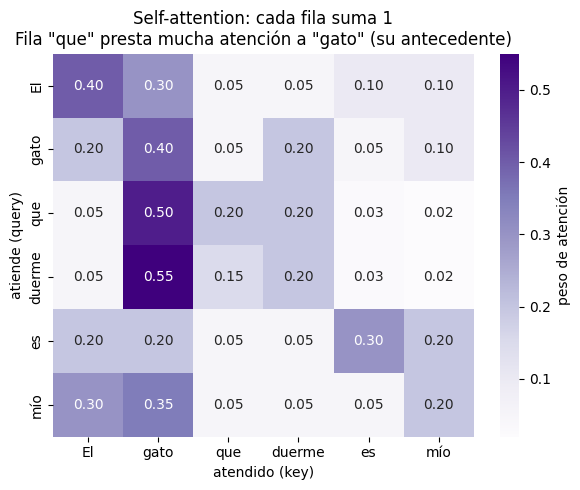

In [2]:
import numpy as np
import seaborn as sns

# Mapa de atención simulado: cada fila atiende a los demás tokens
np.random.seed(0)
tokens = ['El', 'gato', 'que', 'duerme', 'es', 'mío']
n = len(tokens)
# pesos de atención inventados, normalizados por fila
A = np.array([
    [0.40, 0.30, 0.05, 0.05, 0.10, 0.10],
    [0.20, 0.40, 0.05, 0.20, 0.05, 0.10],
    [0.05, 0.50, 0.20, 0.20, 0.03, 0.02],
    [0.05, 0.55, 0.15, 0.20, 0.03, 0.02],
    [0.20, 0.20, 0.05, 0.05, 0.30, 0.20],
    [0.30, 0.35, 0.05, 0.05, 0.05, 0.20],
])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(A, annot=True, fmt='.2f', cmap='Purples',
            xticklabels=tokens, yticklabels=tokens,
            cbar_kws={'label': 'peso de atención'}, ax=ax)
ax.set_xlabel('atendido (key)'); ax.set_ylabel('atiende (query)')
ax.set_title('Self-attention: cada fila suma 1\nFila "que" presta mucha atención a "gato" (su antecedente)')
plt.tight_layout(); plt.show()

### 🤔 Cómo se leen estos números

Pregunta muy común. Los pesos del heatmap **NO son** los tokens predichos, ni la respuesta final del modelo. Son **coeficientes internos** de UNA capa de atención. Para leerlos:

**Qué representa cada número**

- Es una **probabilidad** entre 0 y 1. Dice qué tanto el token de esa **fila** (la _query_) "presta atención" al token de esa **columna** (la _key_) para mezclar información.
- Cada **fila suma 1** (la matriz pasó por softmax). Si la fila de `"que"` tiene `0.50` en la columna `"gato"`, significa: _"para construir mi representación contextualizada, el 50 % del contexto lo tomo del vector de gato"_.
- Un valor alto (0.5–0.9) → "este otro token me importa mucho". Cerca de 0 → "casi lo ignoro".

**Qué NO son**

- ❌ **No son la predicción final.** El modelo no devuelve `"gato"` porque la atención a gato sea alta. La predicción del siguiente token sale **al final**, después de pasar por TODAS las capas + `unembedding` + `softmax` sobre el vocabulario (Paso 5 de la sección 6).
- ❌ **No hay UNA matriz de atención.** Un modelo real apila ~100 capas, cada una con ~16-128 cabezas en paralelo → **miles** de matrices como ésta, capturando relaciones distintas (sintácticas, semánticas, referenciales, …).
- ❌ **No es lo único que pasa.** Después de la atención viene un FFN, otra atención, otro FFN… repetido decenas de veces.

**Cómo se usa el número en práctica**

Cada token tiene tres vectores: $Q$ (query), $K$ (key), $V$ (value). El peso `0.50` se aplica al **value de "gato"** para construir el output del token "que":

```
output("que") = 0.05·V("El") + 0.50·V("gato") + 0.20·V("que")
              + 0.20·V("duerme") + 0.03·V("es") + 0.02·V("mío")
```

Ese `output("que")` es lo que pasa a la siguiente capa.

> 🎯 **En resumen:** el heatmap es un mapa de **dependencias** entre tokens dentro de UNA capa — no un ranking de palabras candidatas a salir. La salida real del modelo se decide en el Paso 5, después de procesar todo el contexto.

## 8. Componentes de un bloque Transformer

Un **bloque Transformer** apila los siguientes módulos:

1. **Multi-Head Self-Attention** — la pieza central explicada en la sección 7.
2. **Add & LayerNorm** — conexiones residuales + normalización para estabilizar el entrenamiento.
3. **Feed-Forward Network (FFN)** — dos capas densas con activación no lineal aplicadas a cada posición.
4. **Add & LayerNorm** otra vez.

Los modelos modernos apilan **decenas o cientos** de estos bloques. GPT-3 tiene 96, GPT-4 muchos más (no público).

**Variantes arquitectónicas:**
- **Encoder-only** (BERT, RoBERTa) — entiende texto, bueno para clasificación.
- **Decoder-only** (GPT, Claude, Llama) — genera texto, predice el siguiente token.
- **Encoder-Decoder** (T5, BART) — bueno para traducción y resumen.

## 9. Pipeline de entrenamiento de un LLM moderno

| Fase | Qué hace | Costo |
|---|---|---|
| **1. Pretraining** | next-token prediction sobre internet entero (libros, web, código) | meses, decenas de millones USD |
| **2. SFT (Supervised Fine-Tuning)** | enseñar formato de instrucción con ejemplos curados | días–semanas |
| **3. RLHF / DPO** | alinear con preferencias humanas (utilidad, seguridad, tono) | días |
| **4. Safety + red teaming** | bloqueo de outputs dañinos | continuo |

El modelo "base" sabe predecir el siguiente token; el modelo "instruct" o "chat" (lo que tú usas vía API) ya pasó por SFT y RLHF y sabe **seguir instrucciones**.

## 10. Familias de modelos — un mapa rápido

**Cerrados (API)**
- **OpenAI**: GPT-3.5, GPT-4, GPT-4o, GPT-5, o1/o3 (reasoning).
- **Anthropic**: Claude 3 → Claude Opus/Sonnet/Haiku 4.x (4.6, 4.7).
- **Google**: Gemini 1.5 / 2.0 / 2.5 Pro / Flash.
- **xAI**: Grok.

**Abiertos (pesos descargables)**
- **Meta**: LLaMA 2, 3, 3.1, 3.3 (8B / 70B / 405B).
- **Mistral**: Mistral 7B, Mixtral 8x7B, Mixtral 8x22B.
- **Qwen** (Alibaba): Qwen2, Qwen2.5.
- **Google**: Gemma 2.
- **Microsoft**: Phi-3, Phi-4.
- **DeepSeek**: V2, V3, R1 (reasoning).

**Multimodales destacados**
- GPT-4o, Claude Opus 4, Gemini — texto + imagen + audio + video.
- Whisper (OpenAI) — speech-to-text.
- DALL·E 3, Stable Diffusion, FLUX — texto-a-imagen.
- Sora, Veo — texto-a-video.

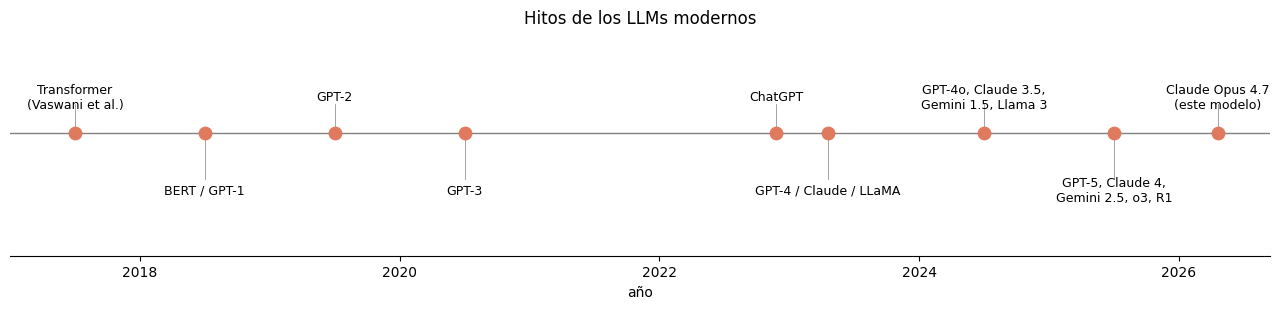

In [3]:
# Línea de tiempo simplificada de modelos clave
fig, ax = plt.subplots(figsize=(13, 3.2))

hitos = [
    (2017.5, 'Transformer\n(Vaswani et al.)'),
    (2018.5, 'BERT / GPT-1'),
    (2019.5, 'GPT-2'),
    (2020.5, 'GPT-3'),
    (2022.9, 'ChatGPT'),
    (2023.3, 'GPT-4 / Claude / LLaMA'),
    (2024.5, 'GPT-4o, Claude 3.5,\nGemini 1.5, Llama 3'),
    (2025.5, 'GPT-5, Claude 4,\nGemini 2.5, o3, R1'),
    (2026.3, 'Claude Opus 4.7\n(este modelo)'),
]
xs = [h[0] for h in hitos]
ax.scatter(xs, [0]*len(xs), s=80, color='#E07A5F', zorder=3)
ax.axhline(0, color='gray', lw=1)
for i, (x, txt) in enumerate(hitos):
    yoff = 0.18 if i % 2 == 0 else -0.28
    ax.text(x, yoff, txt, ha='center', va='center', fontsize=9)
    ax.plot([x, x], [0, yoff*0.8], color='gray', lw=0.5)
ax.set_xlim(2017, 2026.7); ax.set_ylim(-0.6, 0.5)
ax.set_yticks([]); ax.set_xlabel('año')
ax.set_title('Hitos de los LLMs modernos')
ax.spines[['top', 'right', 'left']].set_visible(False)
plt.tight_layout(); plt.show()

## 11. Por qué los Transformers cambiaron la IA

Tres razones que explican la explosión:

1. **Escalabilidad**: el rendimiento mejora **predeciblemente** con más datos, más parámetros y más cómputo (Kaplan et al., 2020 — _Scaling Laws_). Esto convirtió la investigación en ingeniería: si quieres mejor modelo, escalas.
2. **Generalidad**: una sola arquitectura sirve para texto, código, imagen, audio, biología (proteínas), química, robótica.
3. **Acceso vía API**: cualquier desarrollador puede usar un modelo de billones de parámetros con `pip install openai` y una API key. La barrera de entrada cayó de "tener un PhD y un cluster de GPUs" a "tener una tarjeta de crédito".

## 12. Casos de uso típicos

- **Asistentes y chatbots** — soporte, educación, salud.
- **Generación y análisis de código** — Copilot, Cursor, este propio Claude Code.
- **RAG (Retrieval-Augmented Generation)** — preguntar a tu propia documentación.
- **Análisis de documentos** — extraer información de PDFs, contratos, facturas.
- **Búsqueda semántica** — embeddings + vector DB.
- **Multimodal** — analizar imágenes, generar imágenes, transcribir audio.
- **Agentes** — sistemas que toman decisiones y ejecutan herramientas (browse, código, APIs).
- **Productividad personal** — resumir reuniones, redactar emails, traducir.

## 13. Lo que viene en este módulo

- **Notebook 02** — APIs: cómo se consume un modelo (OpenAI, Hugging Face), pricing, chat completions, embeddings y multimodal.
- **Notebook 03** — Prompt engineering, parámetros de generación (temperature, top-p, top-k, max_tokens, …) y tokenización.
- **Notebook 04** — Alternativas al stack de OpenAI: Ollama (modelos open-source corriendo localmente) y Gemini.

## 14. Referencias

- Vaswani, A. et al. (2017). *Attention Is All You Need*. https://arxiv.org/abs/1706.03762
- Bommasani, R. et al. (2021). *On the Opportunities and Risks of Foundation Models*. https://arxiv.org/abs/2108.07258
- Kaplan, J. et al. (2020). *Scaling Laws for Neural Language Models*. https://arxiv.org/abs/2001.08361
- Brown, T. et al. (2020). *Language Models are Few-Shot Learners* (GPT-3). https://arxiv.org/abs/2005.14165
- Wei, J. et al. (2022). *Emergent Abilities of Large Language Models*. https://arxiv.org/abs/2206.07682
- Hugging Face Course (gratis y excelente): https://huggingface.co/learn/nlp-course
- 3Blue1Brown — visualización del Transformer: https://www.youtube.com/watch?v=wjZofJX0v4M
- Karpathy, A. — *Let's build GPT from scratch*: https://www.youtube.com/watch?v=kCc8FmEb1nY